In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
fn = r'f:\TUD_CEG_Repository\MSc_Thesis\Code\notebook\flood_statistics_mozambique.csv'

df = pd.read_csv(fn)
df

,scenario,flooded_cells,flood_extent_m2,flood_extent_km2,mean_depth_m,max_depth_m,volume_m3
0,Baseline,2300270,230027000,230.0270,1.816042,5.534138,417738800.0
1,Erosion 50 Year,2300010,230001000,230.0010,1.835829,7.818748,422242600.0
2,Erosion 100 Year,2303392,230339200,230.3392,1.897448,8.745018,437056700.0
3,Subsidence 50 Year,2651340,265134000,265.1340,2.100544,6.015884,556925650.0
4,Subsidence 100 Year,3059386,305938600,305.9386,2.349417,6.494683,718777250.0
5,Combination 50 Year,2650820,265082000,265.0820,2.118137,8.318506,561479900.0
6,Combination 100 Year,3060597,306059700,306.0597,2.415442,9.746559,739269500.0


In [3]:
scenarios = [
    "Baseline\n(0 yr)",
    "Erosion\n50 yr",
    "Erosion\n100 yr",
    "Subsidence\n50 yr",
    "Subsidence\n100 yr",
    "Combined\n50 yr",
    "Combined\n100 yr"
]

extent = df['flood_extent_km2']
volume = df['volume_m3'] / 1e6
mean_depth = df['mean_depth_m']

400 800 3


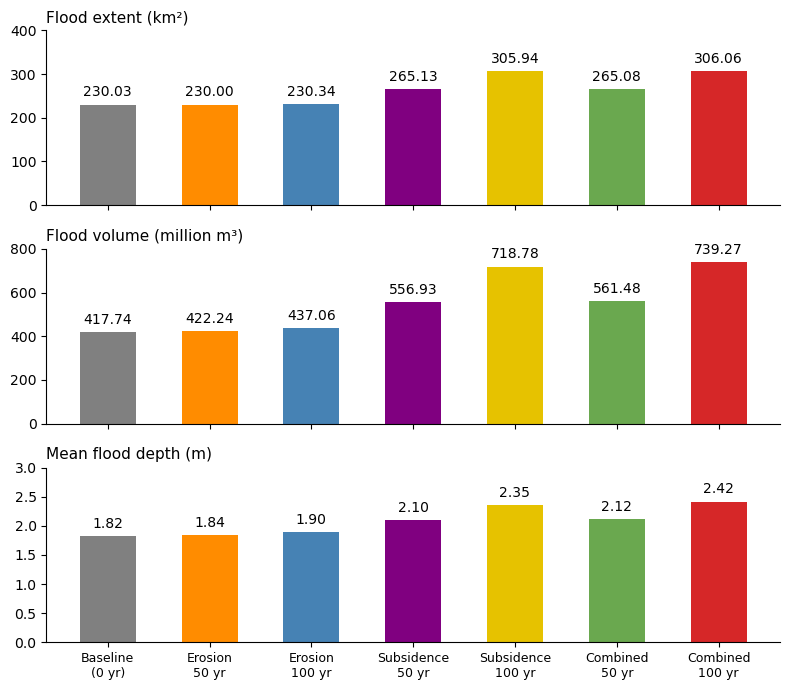

In [4]:


# Data from your figure


# extent = [25.7, 29.8, 31.2, 38.9, 34.6, 37.5, 49.3]      # km2
# volume = [82, 106, 117, 159, 126, 147, 222]               # million m3
# mean_depth = [0.72, 0.86, 0.95, 1.21, 1.02, 1.16, 1.48]   # m



colors = [
    "gray", "darkorange", "steelblue", "purple",
    "#E6C200", "#6AA84F", "#D62728"
]

x = np.arange(len(scenarios))

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 7),
    sharex=True
)

data_list = [extent, volume, mean_depth]
titles = [
    "Flood extent (km²)",
    "Flood volume (million m³)",
    "Mean flood depth (m)"
]

extent_lim = math.ceil(extent.max()/100)*100
volume_lim = math.ceil(volume.max()/100)*100
depth_lim = math.ceil(mean_depth.max()/1)*1

print(extent_lim,volume_lim,depth_lim)

ylims = [(0, extent_lim), (0, volume_lim), (0, depth_lim)]

for ax, data, title, ylim in zip(axes, data_list, titles, ylims):
    bars = ax.bar(x, data, color=colors, width=0.55)

    ax.set_ylim(ylim)
    ax.set_title(title, loc="left", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Value labels
    for bar, val in zip(bars, data):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (ylim[1] * 0.03),
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(scenarios, fontsize=9)

# # Optional: color x labels similar to bars
# for tick, color in zip(axes[-1].get_xticklabels(), colors):
#     tick.set_color(color)
#     tick.set_fontweight("bold" if color != "gray" else "normal")

plt.tight_layout()
# plt.savefig("flood_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
df

,scenario,flooded_cells,flood_extent_m2,flood_extent_km2,mean_depth_m,max_depth_m,volume_m3
0,Baseline,2300270,230027000,230.0270,1.816042,5.534138,417738800.0
1,Erosion 50 Year,2300010,230001000,230.0010,1.835829,7.818748,422242600.0
2,Erosion 100 Year,2303392,230339200,230.3392,1.897448,8.745018,437056700.0
3,Subsidence 50 Year,2651340,265134000,265.1340,2.100544,6.015884,556925650.0
4,Subsidence 100 Year,3059386,305938600,305.9386,2.349417,6.494683,718777250.0
5,Combination 50 Year,2650820,265082000,265.0820,2.118137,8.318506,561479900.0
6,Combination 100 Year,3060597,306059700,306.0597,2.415442,9.746559,739269500.0


[0.        2.0943951 4.1887902]


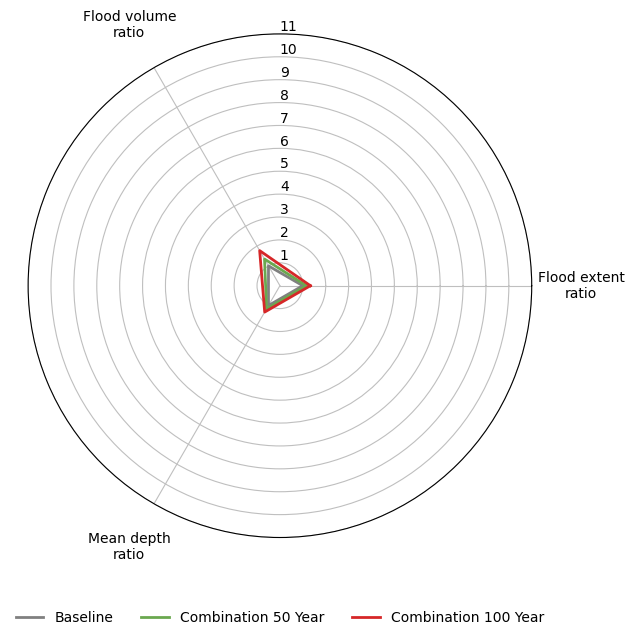

In [6]:
# df["Flood volume\n(million m³)"] = volume
# df["Wet cells\n(×10⁵ cells)"] = extent

extent = df['flood_extent_km2']
volume = df['volume_m3'] / 1e6
mean_depth = df['mean_depth_m']

metrics = [
    'flood_extent_km2',
    'volume_m3',
    'mean_depth_m',
    # "Max Depth (m)",
    # "Wet cells\n(×10⁵ cells)",
]


# normalize to baseline
baseline = df.loc[df["scenario"] == "Baseline", metrics].iloc[0]
values_norm = df[metrics] / baseline

labels = [
    "Flood extent\nratio",
    "Flood volume\nratio",
    "Mean depth\nratio",
    # "Max depth\n(m)",
    # "Wet cells\n(×10⁵ cells)",
]

N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
print(angles)
angles = np.append(angles, angles[0])

colors = [
    "gray", "darkorange", "steelblue", "purple",
    "#E6C200", "#6AA84F", "#D62728"
]

fig, ax = plt.subplots(figsize=(8, 6.5), subplot_kw={"polar": True})

for i, row in df.iterrows():
    # if i == 0:
    #     continue
    if 'Baseline' in row['scenario'] or 'Combination' in row['scenario']:
        vals = values_norm.iloc[i].values
        vals = np.append(vals, vals[0])

        ax.plot(
            angles,
            vals,
            linewidth=2,
            color=colors[i],
            label=row["scenario"]
        )

        #     # add value labels at each point
        # for angle, val in zip(angles[:-1], vals[:-1]):
        #     ax.text(
        #         angle,
        #         val + 0.15,          # offset from point
        #         f"{val:.2f}",        # label format
        #         ha="center",
        #         va="center",
        #         fontsize=8,
        #         color=colors[i]
        #     )
        # print(row['scenario'])
        # if row["scenario"] == "Baseline":
        #     print('baseline')
        #     for angle, val in zip(angles[:-1], vals[:-1]):
        #         ax.text(angle, val + 0.5, f"{val:.2f}",
        #                 ha="center", va="center", fontsize=9)

        # if row["scenario"] == "Combination 50 Year":
        #     print('combi 1')
        #     for angle, val in zip(angles[:-1], vals[:-1]):
        #         ax.text(angle, val + 0.5, f"{val:.2f}",
        #                 ha="center", va="center", fontsize=9)

        # if row["scenario"] == "Combination 100 Year":
        #     print('combi 2')
        #     for angle, val in zip(angles[:-1], vals[:-1]):
        #         ax.text(angle, val + 0.5, f"{val:.2f}",
        #                 ha="left", va="top", fontsize=9)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

ax.set_ylim(0, 11)
ax.set_yticks(np.arange(1, 12, 1))  # draw circles at 2,4,6,8,10
# ax.set_yticklabels([])              # hide numbers
ax.set_rlabel_position(90)    # degrees
ax.grid(color='0.75', linewidth=0.8)
ax.tick_params(axis='x', pad=25)
# ax.set_ylim(0, 10)
# ax.set_yticks(np.arange(0, 10.5, 0.5))
# ax.set_yticklabels([f"{v:.1f}" for v in np.arange(0, 10.5, 0.5)], fontsize=8)

# ax.set_title(
#     "Bohai flood scenario comparison\n(normalized to baseline)",
#     fontsize=13,
#     pad=22
# )

# ax.grid(True)
# ax.legend(
#     loc="center left",
#     bbox_to_anchor=(1.15, 0.5),
#     frameon=True,
#     fontsize=9
# )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 0.78, 1])
# plt.savefig("bohai_spiderweb_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
values_norm.set_index(df['scenario'])

,flood_extent_km2,volume_m3,mean_depth_m
scenario,,,
Baseline,1.000000,1.000000,1.000000
Erosion 50 Year,0.999887,1.010781,1.010896
Erosion 100 Year,1.001357,1.046244,1.044826
Subsidence 50 Year,1.152621,1.333191,1.156660
Subsidence 100 Year,1.330012,1.720638,1.293701
Combination 50 Year,1.152395,1.344093,1.166348
Combination 100 Year,1.330538,1.769693,1.330058


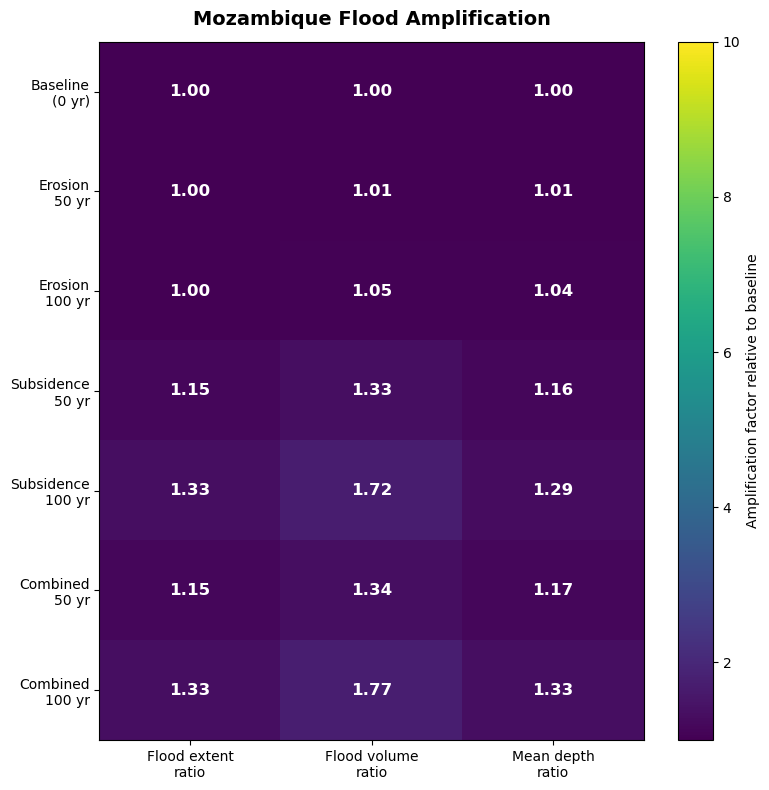

In [12]:
# Amplification data
# df = pd.DataFrame({
#     "Scenario": [
#         "Baseline",
#         "Erosion 50 yr",
#         "Erosion 100 yr",
#         "Subsidence 50 yr",
#         "Subsidence 100 yr",
#         "Combined 50 yr",
#         "Combined 100 yr",
#     ],
#     "Flood extent": [1.000, 1.007, 1.017, 2.668, 4.005, 2.672, 4.006],
#     "Flood volume": [1.000, 1.019, 1.055, 3.842, 9.485, 3.865, 9.545],
#     "Mean depth": [1.000, 1.012, 1.038, 1.440, 2.368, 1.447, 2.382],
#     "Max depth": [1.000, 1.000, 1.000, 1.025, 1.049, 1.025, 1.049],
# })

df_plot = values_norm.set_index(df['scenario'])
# df_plot = df.set_index("scenario")[['flood_extent_km2','volume_m3','mean_depth_m']]

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(df_plot.values, aspect="auto", 
               cmap='viridis',
               vmax=10
               )

# Axis labels
ax.set_xticks(np.arange(len(df_plot.columns)))
ax.set_xticklabels(labels, fontsize=10)

ax.set_yticks(np.arange(len(df_plot.index)))
ax.set_yticklabels(scenarios, fontsize=10)

# Add values inside cells
for i in range(df_plot.shape[0]):
    for j in range(df_plot.shape[1]):
        value = df_plot.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=12,color='white',weight="bold")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Amplification factor relative to baseline", fontsize=10)

ax.set_title("Mozambique Flood Amplification", fontsize=14, weight="bold", pad=12)

plt.tight_layout()
plt.show()

In [10]:
df_plot

,flood_extent_km2,volume_m3,mean_depth_m
scenario,,,
Baseline,1.000000,1.000000,1.000000
Erosion 50 Year,0.999887,1.010781,1.010896
Erosion 100 Year,1.001357,1.046244,1.044826
Subsidence 50 Year,1.152621,1.333191,1.156660
Subsidence 100 Year,1.330012,1.720638,1.293701
Combination 50 Year,1.152395,1.344093,1.166348
Combination 100 Year,1.330538,1.769693,1.330058
